Base Cluster

In [1]:
import numpy as np

# ----------------------------
# PARAMETERS
# ----------------------------
TOTAL_BUDGET = 100
NUM_PLAYERS = 1000
SIMS = 200

MEAN_SPEED = 50
STD_SPEED = 12

LOW_CUT = 0
HIGH_CUT = 90


# ----------------------------
# MODEL COMPONENTS
# ----------------------------

def research(x):
    return 200_000 * np.log(1 + x) / np.log(1 + 100)

def scale(x):
    return 7 * x / 100


def generate_competitors():
    x = np.random.normal(MEAN_SPEED, STD_SPEED, NUM_PLAYERS)
    return np.clip(x, LOW_CUT, HIGH_CUT)


def speed_multiplier(my_speed, others):
    all_speeds = np.append(others, my_speed)

    order = np.argsort(-all_speeds)
    ranks = np.empty_like(order)
    ranks[order] = np.arange(1, len(all_speeds) + 1)

    my_rank = ranks[-1]
    n = len(all_speeds)

    return 0.9 - (my_rank - 1) * (0.8 / (n - 1))


def pnl(r, s, sp):
    total = 0

    for _ in range(SIMS):
        others = generate_competitors()
        sp_mult = speed_multiplier(sp, others)

        total += (research(r) * scale(s) * sp_mult) - (r + s + sp)

    return total / SIMS


# ----------------------------
# GRID SEARCH + STORE RESULTS
# ----------------------------

results = []

step = 5

for r in range(0, TOTAL_BUDGET + 1, step):
    for s in range(0, TOTAL_BUDGET - r + 1, step):
        sp = TOTAL_BUDGET - r - s

        value = pnl(r, s, sp)
        results.append((value, r, s, sp))


# sort by PnL descending
results.sort(reverse=True, key=lambda x: x[0])


# ----------------------------
# PRINT TOP 20
# ----------------------------

print("Top 20 Allocations:\n")
for i in range(20):
    pnl_val, r, s, sp = results[i]
    print(f"{i+1:2d}. R={r:3d}, S={s:3d}, Sp={sp:3d} | PnL={pnl_val:,.2f}")

Top 20 Allocations:

 1. R= 10, S= 30, Sp= 60 | PnL=160,636.32
 2. R= 10, S= 35, Sp= 55 | PnL=160,401.37
 3. R= 15, S= 30, Sp= 55 | PnL=158,245.95
 4. R= 15, S= 25, Sp= 60 | PnL=155,154.19
 5. R= 10, S= 25, Sp= 65 | PnL=148,184.05
 6. R= 15, S= 35, Sp= 50 | PnL=146,728.72
 7. R= 20, S= 25, Sp= 55 | PnL=145,572.80
 8. R= 10, S= 40, Sp= 50 | PnL=145,541.25
 9. R=  5, S= 35, Sp= 60 | PnL=140,357.34
10. R= 20, S= 30, Sp= 50 | PnL=138,652.03
11. R= 15, S= 20, Sp= 65 | PnL=137,135.17
12. R=  5, S= 40, Sp= 55 | PnL=136,580.34
13. R= 20, S= 20, Sp= 60 | PnL=136,224.55
14. R=  5, S= 30, Sp= 65 | PnL=132,698.22
15. R= 10, S= 20, Sp= 70 | PnL=125,224.00
16. R= 15, S= 40, Sp= 45 | PnL=124,838.10
17. R= 25, S= 20, Sp= 55 | PnL=124,633.20
18. R= 25, S= 25, Sp= 50 | PnL=123,391.84
19. R=  5, S= 45, Sp= 50 | PnL=122,185.78
20. R= 10, S= 45, Sp= 45 | PnL=121,427.69


Near 90

In [3]:
TOTAL_BUDGET = 100
NUM_PLAYERS = 1000
SIMS = 200

LOW_CUT, HIGH_CUT = 0, 90


def research(x):
    return 200_000 * np.log(1 + x) / np.log(1 + 100)

def scale(x):
    return 7 * x / 100


def generate_competitors():
    x = np.random.normal(70, 10, NUM_PLAYERS)
    return np.clip(x, LOW_CUT, HIGH_CUT)


def speed_multiplier(my_speed, others):
    all_speeds = np.append(others, my_speed)
    order = np.argsort(-all_speeds)
    ranks = np.empty_like(order)
    ranks[order] = np.arange(1, len(all_speeds) + 1)
    my_rank = ranks[-1]
    n = len(all_speeds)
    return 0.9 - (my_rank - 1) * (0.8 / (n - 1))


def pnl(r, s, sp):
    total = 0
    for _ in range(SIMS):
        others = generate_competitors()
        sp_mult = speed_multiplier(sp, others)
        total += (research(r) * scale(s) * sp_mult) - (r + s + sp)
    return total / SIMS


results = []
step = 5

for r in range(0, TOTAL_BUDGET + 1, step):
    for s in range(0, TOTAL_BUDGET - r + 1, step):
        sp = TOTAL_BUDGET - r - s
        results.append((pnl(r, s, sp), r, s, sp))

results.sort(reverse=True)

print("HIGH SPEED TILT TOP 20\n")
for i in range(20):
    v, r, s, sp = results[i]
    print(i+1, r, s, sp, v)

HIGH SPEED TILT TOP 20

1 25 75 0 74025.93782629994
2 20 80 0 73784.63893428433
3 30 70 0 72819.16750851781
4 10 20 70 72553.0305248526
5 15 85 0 71390.67001447508
6 10 15 75 71229.44768201103
7 5 20 75 70889.9935732464
8 35 65 0 70559.0916119129
9 20 75 5 69166.84900089155
10 25 70 5 69084.20863788002
11 5 25 70 67932.7475298456
12 30 65 5 67610.6555436235
13 40 60 0 67490.87925544893
14 15 80 5 67185.33648421231
15 10 90 0 65366.28701678723
16 35 60 5 65123.77687253487
17 20 70 10 64549.05906749877
18 25 65 10 64142.479449459825
19 45 55 0 63778.15582580619
20 10 25 65 63016.77471607389


Near 0

In [4]:
TOTAL_BUDGET = 100
NUM_PLAYERS = 1000
SIMS = 200

LOW_CUT, HIGH_CUT = 0, 90


def research(x):
    return 200_000 * np.log(1 + x) / np.log(1 + 100)

def scale(x):
    return 7 * x / 100


def generate_competitors():
    x = np.random.normal(20, 10, NUM_PLAYERS)
    return np.clip(x, LOW_CUT, HIGH_CUT)


def speed_multiplier(my_speed, others):
    all_speeds = np.append(others, my_speed)
    order = np.argsort(-all_speeds)
    ranks = np.empty_like(order)
    ranks[order] = np.arange(1, len(all_speeds) + 1)
    my_rank = ranks[-1]
    n = len(all_speeds)
    return 0.9 - (my_rank - 1) * (0.8 / (n - 1))


def pnl(r, s, sp):
    total = 0
    for _ in range(SIMS):
        others = generate_competitors()
        sp_mult = speed_multiplier(sp, others)
        total += (research(r) * scale(s) * sp_mult) - (r + s + sp)
    return total / SIMS


results = []
step = 5

for r in range(0, TOTAL_BUDGET + 1, step):
    for s in range(0, TOTAL_BUDGET - r + 1, step):
        sp = TOTAL_BUDGET - r - s
        results.append((pnl(r, s, sp), r, s, sp))

results.sort(reverse=True)

print("LOW SPEED TILT TOP 20\n")
for i in range(20):
    v, r, s, sp = results[i]
    print(i+1, r, s, sp, v)

LOW SPEED TILT TOP 20

1 15 55 30 357453.605223739
2 20 50 30 357222.7379299586
3 15 50 35 356027.8289436383
4 20 45 35 351443.666184116
5 25 45 30 343792.16685380094
6 10 55 35 338554.33860572346
7 10 60 30 337257.37871960184
8 25 40 35 334484.32109282835
9 15 45 40 333670.9301900291
10 20 55 25 331506.4505024913
11 15 60 25 329159.44837876275
12 20 40 40 325571.66688009514
13 25 50 25 322017.7220346175
14 30 40 30 321642.70118118264
15 10 50 40 320556.7834209815
16 30 35 35 308578.50313035655
17 10 65 25 308375.83509736246
18 30 45 25 306088.6260706586
19 25 35 40 304908.2695693024
20 15 40 45 301013.99212741724


Clustered Middle

In [5]:
TOTAL_BUDGET = 100
NUM_PLAYERS = 1000
SIMS = 200

LOW_CUT, HIGH_CUT = 0, 90


def research(x):
    return 200_000 * np.log(1 + x) / np.log(1 + 100)

def scale(x):
    return 7 * x / 100


def generate_competitors():
    x = np.random.normal(50, 5, NUM_PLAYERS)
    return np.clip(x, LOW_CUT, HIGH_CUT)


def speed_multiplier(my_speed, others):
    all_speeds = np.append(others, my_speed)
    order = np.argsort(-all_speeds)
    ranks = np.empty_like(order)
    ranks[order] = np.arange(1, len(all_speeds) + 1)
    my_rank = ranks[-1]
    n = len(all_speeds)
    return 0.9 - (my_rank - 1) * (0.8 / (n - 1))


def pnl(r, s, sp):
    total = 0
    for _ in range(SIMS):
        others = generate_competitors()
        sp_mult = speed_multiplier(sp, others)
        total += (research(r) * scale(s) * sp_mult) - (r + s + sp)
    return total / SIMS


results = []
step = 5

for r in range(0, TOTAL_BUDGET + 1, step):
    for s in range(0, TOTAL_BUDGET - r + 1, step):
        sp = TOTAL_BUDGET - r - s
        results.append((pnl(r, s, sp), r, s, sp))

results.sort(reverse=True)

print("TIGHT MIDDLE TOP 20\n")
for i in range(20):
    v, r, s, sp = results[i]
    print(i+1, r, s, sp, v)

TIGHT MIDDLE TOP 20

1 10 35 55 196654.12476790708
2 15 30 55 195004.9352164932
3 10 30 60 192331.60405714533
4 15 25 60 185303.06254883466
5 20 25 55 178166.08614668075
6 5 40 55 167792.95887277185
7 5 35 60 167640.9874726589
8 10 25 65 163366.40906816235
9 20 20 60 162736.57228643683
10 25 20 55 152721.19612938017
11 15 20 65 151113.0280944295
12 15 35 50 147111.40092037214
13 5 30 65 146496.96089870972
14 10 40 50 145615.7345257925
15 20 30 50 138072.40211739417
16 10 20 70 130830.24634336945
17 25 15 60 130583.4353802638
18 20 15 65 124420.18324671451
19 25 25 50 123518.34399416365
20 5 45 50 122334.48663739489


Fat Tails

In [6]:
TOTAL_BUDGET = 100
NUM_PLAYERS = 1000
SIMS = 200

LOW_CUT, HIGH_CUT = 0, 90


def research(x):
    return 200_000 * np.log(1 + x) / np.log(1 + 100)

def scale(x):
    return 7 * x / 100


def generate_competitors():
    base = np.random.normal(50, 15, NUM_PLAYERS)
    shock = np.random.choice([0, 1], size=NUM_PLAYERS, p=[0.85, 0.15])
    tail = np.random.choice([-40, 40], size=NUM_PLAYERS)
    x = base + shock * tail
    return np.clip(x, LOW_CUT, HIGH_CUT)


def speed_multiplier(my_speed, others):
    all_speeds = np.append(others, my_speed)
    order = np.argsort(-all_speeds)
    ranks = np.empty_like(order)
    ranks[order] = np.arange(1, len(all_speeds) + 1)
    my_rank = ranks[-1]
    n = len(all_speeds)
    return 0.9 - (my_rank - 1) * (0.8 / (n - 1))


def pnl(r, s, sp):
    total = 0
    for _ in range(SIMS):
        others = generate_competitors()
        sp_mult = speed_multiplier(sp, others)
        total += (research(r) * scale(s) * sp_mult) - (r + s + sp)
    return total / SIMS


results = []
step = 5

for r in range(0, TOTAL_BUDGET + 1, step):
    for s in range(0, TOTAL_BUDGET - r + 1, step):
        sp = TOTAL_BUDGET - r - s
        results.append((pnl(r, s, sp), r, s, sp))

results.sort(reverse=True)

print("FAT TAIL TOP 20\n")
for i in range(20):
    v, r, s, sp = results[i]
    print(i+1, r, s, sp, v)

FAT TAIL TOP 20

1 10 35 55 149985.53644384426
2 15 30 55 148305.54742962573
3 15 35 50 146775.8153046571
4 10 30 60 145982.34573308667
5 10 40 50 145466.7623526698
6 15 25 60 140460.75004893146
7 20 30 50 138243.0756333323
8 15 40 45 137891.4594752817
9 20 25 55 136268.87808100833
10 10 45 45 134324.5457830506
11 10 25 65 133663.62724545656
12 20 35 45 132352.99221749115
13 5 40 55 128099.50756886356
14 5 35 60 127177.02595129635
15 15 45 40 125025.49385945307
16 20 20 60 123742.47639608971
17 15 20 65 123476.24898690409
18 25 25 50 123385.90565191397
19 5 45 50 122410.79845633573
20 20 40 40 121766.80115098692


In [7]:
# ----------------------------
# GLOBAL SETTINGS
# ----------------------------
TOTAL_BUDGET = 100
NUM_PLAYERS = 1000
SIMS = 200

LOW_CUT, HIGH_CUT = 0, 70


# ----------------------------
# CORE MODEL
# ----------------------------

def research(x):
    return 200_000 * np.log(1 + x) / np.log(1 + 100)

def scale(x):
    return 7 * x / 100


def speed_multiplier(my_speed, others):
    all_speeds = np.append(others, my_speed)
    order = np.argsort(-all_speeds)

    ranks = np.empty_like(order)
    ranks[order] = np.arange(1, len(all_speeds) + 1)

    my_rank = ranks[-1]
    n = len(all_speeds)

    return 0.9 - (my_rank - 1) * (0.8 / (n - 1))


def pnl(r, s, sp, gen_func):
    total = 0

    for _ in range(SIMS):
        others = gen_func()
        sp_mult = speed_multiplier(sp, others)

        total += (research(r) * scale(s) * sp_mult) - (r + s + sp)

    return total / SIMS


# ----------------------------
# REGIMES
# ----------------------------

def regime_1():
    # BASE: normal around 45 + mild bimodal pressure
    x = np.random.normal(50, 10, NUM_PLAYERS)
    return np.clip(x, LOW_CUT, HIGH_CUT)


def regime_2():
    # TILTED HIGH (crowded near 65-70 cap)
    x = np.random.normal(60, 8, NUM_PLAYERS)
    return np.clip(x, LOW_CUT, HIGH_CUT)


def regime_3():
    # TILTED LOW (mass near 0–40)
    x = np.random.normal(30, 12, NUM_PLAYERS)
    return np.clip(x, LOW_CUT, HIGH_CUT)


def regime_4():
    # TIGHT MIDDLE CLUSTER (very competitive band 45–60)
    x = np.random.normal(52, 4, NUM_PLAYERS)
    return np.clip(x, LOW_CUT, HIGH_CUT)


def regime_5():
    # FAT TAILS (mixture: 0 cluster + 65 cluster + shocks)
    base = np.random.choice([0, 65], size=NUM_PLAYERS, p=[0.5, 0.5])
    noise = np.random.normal(0, 6, NUM_PLAYERS)
    x = base + noise
    return np.clip(x, LOW_CUT, HIGH_CUT)


regimes = [
    ("BASE CASE (Balanced Market)",
     "Normal distribution around 50 with mild dispersion.",
     regime_1),

    ("HIGH SPEED CROWDING",
     "Mass concentrated near upper bound ~65–70.",
     regime_2),

    ("LOW SPEED MARKET",
     "Most competitors underinvest in speed (0–40 cluster).",
     regime_3),

    ("TIGHT MIDDLE WARZONE",
     "Extreme clustering around 45–60; rank is highly sensitive.",
     regime_4),

    ("FAT TAIL / BIFURCATED MARKET",
     "Bimodal: players split between 0-speed and 65-speed regimes.",
     regime_5),
]


# ----------------------------
# GRID SEARCH
# ----------------------------

step = 5

for name, desc, gen_func in regimes:

    results = []

    for r in range(0, TOTAL_BUDGET + 1, step):
        for s in range(0, TOTAL_BUDGET - r + 1, step):
            sp = TOTAL_BUDGET - r - s
            val = pnl(r, s, sp, gen_func)
            results.append((val, r, s, sp))

    results.sort(reverse=True)

    print("\n" + "="*70)
    print(name)
    print(desc)
    print("="*70)
    print("Top 5 allocations:\n")

    for i in range(5):
        v, r, s, sp = results[i]
        print(f"{i+1}. R={r:3d}, S={s:3d}, Sp={sp:3d} | PnL={v:,.2f}")


BASE CASE (Balanced Market)
Normal distribution around 50 with mild dispersion.
Top 5 allocations:

1. R= 10, S= 30, Sp= 60 | PnL=168,665.10
2. R= 10, S= 35, Sp= 55 | PnL=166,195.86
3. R= 15, S= 30, Sp= 55 | PnL=164,709.38
4. R= 15, S= 25, Sp= 60 | PnL=162,286.43
5. R= 10, S= 25, Sp= 65 | PnL=153,753.05

HIGH SPEED CROWDING
Mass concentrated near upper bound ~65–70.
Top 5 allocations:

1. R= 10, S= 20, Sp= 70 | PnL=128,755.11
2. R= 10, S= 25, Sp= 65 | PnL=124,917.33
3. R=  5, S= 25, Sp= 70 | PnL=119,899.79
4. R= 15, S= 20, Sp= 65 | PnL=115,369.04
5. R=  5, S= 30, Sp= 65 | PnL=111,733.34

LOW SPEED MARKET
Most competitors underinvest in speed (0–40 cluster).
Top 5 allocations:

1. R= 15, S= 45, Sp= 40 | PnL=278,597.55
2. R= 15, S= 40, Sp= 45 | PnL=274,163.11
3. R= 20, S= 40, Sp= 40 | PnL=272,673.22
4. R= 10, S= 50, Sp= 40 | PnL=268,201.21
5. R= 10, S= 45, Sp= 45 | PnL=266,610.96

TIGHT MIDDLE WARZONE
Extreme clustering around 45–60; rank is highly sensitive.
Top 5 allocations:

1. R= 1

More Likely Clustering Rules

In [12]:
# ----------------------------
# PARAMETERS
# ----------------------------
TOTAL_BUDGET = 100
NUM_PLAYERS = 1000
SIMS = 200

LOW_CUT, HIGH_CUT = 0, 70


def research(x):
    return 200_000 * np.log(1 + x) / np.log(1 + 100)

def scale(x):
    return 7 * x / 100


# ----------------------------
# MIXED SPEED DISTRIBUTION
# ----------------------------
def generate_competitors():
    n = NUM_PLAYERS

    # 25% low cluster (0–20)
    low = np.random.uniform(0, 20, int(0.25 * n))

    # 15% high cluster (70–80, then clipped)
    high = np.random.uniform(70, 80, int(0.15 * n))

    # 60% normal around 50
    mid = np.random.normal(50, 8, n - len(low) - len(high))

    x = np.concatenate([low, high, mid])

    return np.clip(x, LOW_CUT, HIGH_CUT)


def speed_multiplier(my_speed, others):
    all_speeds = np.append(others, my_speed)
    order = np.argsort(-all_speeds)

    ranks = np.empty_like(order)
    ranks[order] = np.arange(1, len(all_speeds) + 1)

    my_rank = ranks[-1]
    n = len(all_speeds)

    return 0.9 - (my_rank - 1) * (0.8 / (n - 1))


def pnl(r, s, sp):
    total = 0

    for _ in range(SIMS):
        others = generate_competitors()
        sp_mult = speed_multiplier(sp, others)

        total += (research(r) * scale(s) * sp_mult) - (r + s + sp)

    return total / SIMS


# ----------------------------
# GRID SEARCH
# ----------------------------
results = []
step = 3

for r in range(0, TOTAL_BUDGET + 1, step):
    for s in range(0, TOTAL_BUDGET - r + 1, step):
        sp = TOTAL_BUDGET - r - s
        results.append((pnl(r, s, sp), r, s, sp))

results.sort(reverse=True)

print("MIXED DISTRIBUTION TOP 10\n")
for i in range(10):
    v, r, s, sp = results[i]
    print(f"{i+1}. R={r}, S={s}, Sp={sp} | PnL={v:,.2f}")

MIXED DISTRIBUTION TOP 10

1. R=12, S=33, Sp=55 | PnL=167,564.17
2. R=15, S=30, Sp=55 | PnL=164,385.40
3. R=12, S=36, Sp=52 | PnL=164,229.57
4. R=12, S=30, Sp=58 | PnL=164,119.21
5. R=9, S=36, Sp=55 | PnL=163,853.78
6. R=21, S=60, Sp=19 | PnL=163,095.06
7. R=15, S=33, Sp=52 | PnL=163,006.22
8. R=18, S=63, Sp=19 | PnL=162,952.15
9. R=9, S=33, Sp=58 | PnL=162,174.30
10. R=24, S=57, Sp=19 | PnL=161,491.67


Double Distribution

In [15]:
# ----------------------------
# PARAMETERS
# ----------------------------
TOTAL_BUDGET = 100
NUM_PLAYERS = 1000
SIMS = 200

LOW_CUT, HIGH_CUT = 0, 80


def research(x):
    return 200_000 * np.log(1 + x) / np.log(1 + 100)

def scale(x):
    return 7 * x / 100


# ----------------------------
# BIASED BIMODAL DISTRIBUTION
# ----------------------------
def generate_competitors():
    n = NUM_PLAYERS

    # More mass on low-speed regime (65%)
    low = np.random.normal(20, 4, int(0.65 * n))

    # Less mass on high-speed regime (35%)
    high = np.random.normal(65, 6, n - len(low))

    x = np.concatenate([low, high])

    return np.clip(x, LOW_CUT, HIGH_CUT)


# ----------------------------
# SPEED MECHANISM
# ----------------------------
def speed_multiplier(my_speed, others):
    all_speeds = np.append(others, my_speed)
    order = np.argsort(-all_speeds)

    ranks = np.empty_like(order)
    ranks[order] = np.arange(1, len(all_speeds) + 1)

    my_rank = ranks[-1]
    n = len(all_speeds)

    return 0.9 - (my_rank - 1) * (0.8 / (n - 1))


# ----------------------------
# PnL FUNCTION
# ----------------------------
def pnl(r, s, sp):
    total = 0

    for _ in range(SIMS):
        others = generate_competitors()
        sp_mult = speed_multiplier(sp, others)

        total += (research(r) * scale(s) * sp_mult) - (r + s + sp)

    return total / SIMS


# ----------------------------
# GRID SEARCH
# ----------------------------
results = []
step = 3

for r in range(0, TOTAL_BUDGET + 1, step):
    for s in range(0, TOTAL_BUDGET - r + 1, step):
        sp = TOTAL_BUDGET - r - s
        results.append((pnl(r, s, sp), r, s, sp))

results.sort(reverse=True)

print("BI-MODAL (12 HEAVY / 65 LIGHT) TOP 10\n")

for i in range(10):
    v, r, s, sp = results[i]
    print(f"{i+1}. R={r}, S={s}, Sp={sp} | PnL={v:,.2f}")

BI-MODAL (12 HEAVY / 65 LIGHT) TOP 10

1. R=18, S=54, Sp=28 | PnL=293,160.42
2. R=15, S=57, Sp=28 | PnL=291,351.31
3. R=21, S=51, Sp=28 | PnL=290,601.03
4. R=18, S=57, Sp=25 | PnL=287,694.81
5. R=21, S=54, Sp=25 | PnL=286,029.66
6. R=15, S=60, Sp=25 | PnL=285,041.80
7. R=24, S=48, Sp=28 | PnL=284,834.77
8. R=12, S=60, Sp=28 | PnL=283,715.27
9. R=18, S=51, Sp=31 | PnL=281,598.41
10. R=24, S=51, Sp=25 | PnL=281,596.21


In [17]:
# ----------------------------
# PARAMETERS
# ----------------------------
TOTAL_BUDGET = 100
NUM_PLAYERS = 1000
SIMS = 150

CAPS = [60, 65, 70, 75]

step = 5

# ----------------------------
# CORE FUNCTIONS
# ----------------------------

def research(x):
    return 200_000 * np.log(1 + x) / np.log(1 + 100)

def scale(x):
    return 7 * x / 100


# ----------------------------
# COMPETITOR DISTRIBUTION
# ----------------------------
def generate_competitors(cap):
    # stable mixed market
    low = np.random.normal(12, 4, int(0.3 * NUM_PLAYERS))
    mid = np.random.normal(50, 8, int(0.5 * NUM_PLAYERS))
    high = np.random.normal(65, 6, NUM_PLAYERS - len(low) - len(mid))

    x = np.concatenate([low, mid, high])
    return np.clip(x, 0, cap)


# ----------------------------
# SPEED FUNCTION
# ----------------------------
def speed_multiplier(my_speed, others):
    all_speeds = np.append(others, my_speed)
    order = np.argsort(-all_speeds)

    ranks = np.empty_like(order)
    ranks[order] = np.arange(1, len(all_speeds) + 1)

    my_rank = ranks[-1]
    n = len(all_speeds)

    return 0.9 - (my_rank - 1) * (0.8 / (n - 1))


# ----------------------------
# PnL
# ----------------------------
def pnl(r, s, sp, cap):
    total = 0

    for _ in range(SIMS):
        others = generate_competitors(cap)
        sp_mult = speed_multiplier(sp, others)

        total += (research(r) * scale(s) * sp_mult) - (r + s + sp)

    return total / SIMS


# ----------------------------
# GRID SEARCH OVER CAPS
# ----------------------------
for cap in CAPS:

    results = []

    for r in range(0, TOTAL_BUDGET + 1, step):
        for s in range(0, TOTAL_BUDGET - r + 1, step):
            sp = TOTAL_BUDGET - r - s
            results.append((pnl(r, s, sp, cap), r, s, sp))

    results.sort(reverse=True)

    print("\n" + "=" * 60)
    print(f"HARD CAP = {cap}")
    print("=" * 60)
    print("Top 5 allocations:\n")

    for i in range(5):
        v, r, s, sp = results[i]
        print(f"{i+1}. R={r:3d}, S={s:3d}, Sp={sp:3d} | PnL={v:,.2f}")


HARD CAP = 60
Top 5 allocations:

1. R= 20, S= 60, Sp= 20 | PnL=185,273.60
2. R= 10, S= 30, Sp= 60 | PnL=183,474.45
3. R= 15, S= 65, Sp= 20 | PnL=182,725.92
4. R= 25, S= 55, Sp= 20 | PnL=181,818.62
5. R= 15, S= 25, Sp= 60 | PnL=176,772.96

HARD CAP = 65
Top 5 allocations:

1. R= 20, S= 60, Sp= 20 | PnL=185,244.05
2. R= 15, S= 65, Sp= 20 | PnL=182,623.87
3. R= 25, S= 55, Sp= 20 | PnL=181,653.37
4. R= 30, S= 50, Sp= 20 | PnL=174,411.54
5. R= 20, S= 55, Sp= 25 | PnL=172,740.80

HARD CAP = 70
Top 5 allocations:

1. R= 20, S= 60, Sp= 20 | PnL=185,332.71
2. R= 15, S= 65, Sp= 20 | PnL=182,848.38
3. R= 25, S= 55, Sp= 20 | PnL=181,775.14
4. R= 30, S= 50, Sp= 20 | PnL=174,047.64
5. R= 20, S= 55, Sp= 25 | PnL=172,765.18

HARD CAP = 75
Top 5 allocations:

1. R= 20, S= 60, Sp= 20 | PnL=185,388.86
2. R= 15, S= 65, Sp= 20 | PnL=182,725.92
3. R= 25, S= 55, Sp= 20 | PnL=181,780.94
4. R= 30, S= 50, Sp= 20 | PnL=174,069.86
5. R= 20, S= 55, Sp= 25 | PnL=172,727.25


In [20]:
# ----------------------------
# PARAMETERS
# ----------------------------
TOTAL_BUDGET = 100
NUM_PLAYERS = 1000
SIMS = 150

step = 5


# ----------------------------
# CORE FUNCTIONS
# ----------------------------

def research(x):
    return 200_000 * np.log(1 + x) / np.log(1 + 100)

def scale(x):
    return 7 * x / 100


# ----------------------------
# SPEED MULTIPLIER
# ----------------------------
def speed_multiplier(my_speed, others):
    all_speeds = np.append(others, my_speed)
    order = np.argsort(-all_speeds)

    ranks = np.empty_like(order)
    ranks[order] = np.arange(1, len(all_speeds) + 1)

    my_rank = ranks[-1]
    n = len(all_speeds)

    return 0.9 - (my_rank - 1) * (0.8 / (n - 1))


# ----------------------------
# REGIME 1 (LESS DENSE MIDDLE)
# ----------------------------
# 20% around 62 (clip 78)
# 30% around 15
# 50% around 40 BUT sparser (mixture noise instead of tight normal)
def gen_regime_1():
    n = NUM_PLAYERS

    high = np.random.normal(62, 5, int(0.2 * n))
    low = np.random.normal(15, 5, int(0.3 * n))

    # sparser middle: mixture instead of single normal
    mid_core = np.random.normal(40, 4, int(0.25 * n))
    mid_noise = np.random.uniform(20, 60, n - len(high) - len(low) - len(mid_core))

    x = np.concatenate([high, low, mid_core, mid_noise])

    return np.clip(x, 0, 78)


# ----------------------------
# REGIME 2 (LESS DENSE + LOWER ZERO MASS)
# ----------------------------
# 35% around 55 (clip 70)
# 30% around 20
# 0–4% at 0 (reduced)
# 28% around 35 but more dispersed
def gen_regime_2():
    n = NUM_PLAYERS

    high = np.random.normal(55, 6, int(0.35 * n))
    low = np.random.normal(20, 6, int(0.30 * n))

    zero_mass = np.zeros(int(0.04 * n))  # reduced from 7% → 4%

    mid_core = np.random.normal(35, 5, int(0.25 * n))
    mid_noise = np.random.uniform(10, 60, n - len(high) - len(low) - len(zero_mass) - len(mid_core))

    x = np.concatenate([high, low, zero_mass, mid_core, mid_noise])

    return np.clip(x, 0, 70)


# ----------------------------
# PnL FUNCTION
# ----------------------------
def pnl(r, s, sp, gen_func):
    total = 0

    for _ in range(SIMS):
        others = gen_func()
        sp_mult = speed_multiplier(sp, others)

        total += (research(r) * scale(s) * sp_mult) - (r + s + sp)

    return total / SIMS


# ----------------------------
# GRID SEARCH
# ----------------------------
def run_case(name, gen_func):

    results = []

    for r in range(0, TOTAL_BUDGET + 1, step):
        for s in range(0, TOTAL_BUDGET - r + 1, step):
            sp = TOTAL_BUDGET - r - s
            results.append((pnl(r, s, sp, gen_func), r, s, sp))

    results.sort(reverse=True)

    print("\n" + "=" * 70)
    print(name)
    print("=" * 70)

    for i in range(5):
        v, r, s, sp = results[i]
        print(f"{i+1}. R={r:3d}, S={s:3d}, Sp={sp:3d} | PnL={v:,.2f}")


# ----------------------------
# RUN BOTH REGIMES
# ----------------------------
run_case(
    "REGIME 1: sparser middle (20% @62, 30% @15, dispersed 40)",
    gen_regime_1
)

run_case(
    "REGIME 2: sparser + 4% zero mass (55 / 20 / 35 structure)",
    gen_regime_2
)


REGIME 1: sparser middle (20% @62, 30% @15, dispersed 40)
1. R= 15, S= 40, Sp= 45 | PnL=216,680.79
2. R= 10, S= 45, Sp= 45 | PnL=210,888.24
3. R= 20, S= 35, Sp= 45 | PnL=208,176.86
4. R= 15, S= 45, Sp= 40 | PnL=204,919.09
5. R= 15, S= 35, Sp= 50 | PnL=202,961.09

REGIME 2: sparser + 4% zero mass (55 / 20 / 35 structure)
1. R= 15, S= 45, Sp= 40 | PnL=215,863.73
2. R= 20, S= 40, Sp= 40 | PnL=210,877.09
3. R= 15, S= 50, Sp= 35 | PnL=207,800.48
4. R= 10, S= 50, Sp= 40 | PnL=207,184.69
5. R= 15, S= 40, Sp= 45 | PnL=206,607.73


In [29]:
# ----------------------------
# PARAMETERS
# ----------------------------
TOTAL_BUDGET = 100
NUM_PLAYERS = 1000
SIMS = 150

step = 2


# ----------------------------
# CORE FUNCTIONS
# ----------------------------

def research(x):
    return 200_000 * np.log(1 + x) / np.log(1 + 100)

def scale(x):
    return 7 * x / 100


# ----------------------------
# SPEED MECHANISM
# ----------------------------
def speed_multiplier(my_speed, others):
    all_speeds = np.append(others, my_speed)
    order = np.argsort(-all_speeds)

    ranks = np.empty_like(order)
    ranks[order] = np.arange(1, len(all_speeds) + 1)

    my_rank = ranks[-1]
    n = len(all_speeds)

    return 0.9 - (my_rank - 1) * (0.8 / (n - 1))


# ----------------------------
# COMPETITOR DISTRIBUTION
# ----------------------------
def generate_competitors():
    n = NUM_PLAYERS

    # 65% high cluster around 65 (clip 78)
    high = np.random.normal(67, 5, int(0.70 * n))

    # 20% low cluster around 22 (clip 0)
    low = np.random.normal(20, 5, int(0.15 * n))

    # 15% wide middle (diffuse, not tightly clustered)
    mid = np.random.uniform(37, 60, n - len(high) - len(low))

    x = np.concatenate([high, low, mid])

    return np.clip(x, 0, 82)


# ----------------------------
# PnL FUNCTION
# ----------------------------
def pnl(r, s, sp):
    total = 0

    for _ in range(SIMS):
        others = generate_competitors()
        sp_mult = speed_multiplier(sp, others)

        total += (research(r) * scale(s) * sp_mult) - (r + s + sp)

    return total / SIMS


# ----------------------------
# GRID SEARCH
# ----------------------------
results = []

for r in range(0, TOTAL_BUDGET + 1, step):
    for s in range(0, TOTAL_BUDGET - r + 1, step):
        sp = TOTAL_BUDGET - r - s
        results.append((pnl(r, s, sp), r, s, sp))

results.sort(reverse=True)


# ----------------------------
# OUTPUT
# ----------------------------
print("\n" + "=" * 70)
print("REGIME: 50% @65 (clip 78), 20% @20, 30% wide middle")
print("=" * 70)
print("Top 5 allocations:\n")

for i in range(5):
    v, r, s, sp = results[i]
    print(f"{i+1}. R={r:3d}, S={s:3d}, Sp={sp:3d} | PnL={v:,.2f}")


REGIME: 50% @65 (clip 78), 20% @20, 30% wide middle
Top 5 allocations:

1. R=  8, S= 22, Sp= 70 | PnL=109,193.86
2. R= 10, S= 20, Sp= 70 | PnL=108,614.00
3. R=  8, S= 20, Sp= 72 | PnL=107,998.66
4. R= 10, S= 22, Sp= 68 | PnL=106,363.89
5. R= 10, S= 18, Sp= 72 | PnL=106,105.52


In [25]:
# ----------------------------
# PARAMETERS
# ----------------------------
TOTAL_BUDGET = 100
FIXED_SP = 72

step = 0.1  # finer resolution for accuracy


# ----------------------------
# CORE FUNCTIONS
# ----------------------------
def research(x):
    return 200_000 * np.log(1 + x) / np.log(1 + 100)

def scale(x):
    return 7 * x / 100


# ----------------------------
# SPEED IS A CONSTANT MULTIPLIER
# (irrelevant for argmax over R,S)
# ----------------------------
def theta_fixed_speed():
    return 1.0  # constant scaling ignored for argmax


# ----------------------------
# OBJECTIVE (R,S ONLY)
# ----------------------------
def pnl(r, s):
    sp = FIXED_SP
    return (research(r) * scale(s) * theta_fixed_speed()) - (r + s + sp)


# ----------------------------
# GRID SEARCH OVER R,S
# ----------------------------
results = []

for r in np.arange(0, TOTAL_BUDGET - FIXED_SP + step, step):
    s = TOTAL_BUDGET - FIXED_SP - r
    val = pnl(r, s)
    results.append((val, r, s))

results.sort(reverse=True)


# ----------------------------
# OUTPUT
# ----------------------------
best_val, best_r, best_s = results[0]

print("\n===================================")
print("OPTIMIZATION WITH FIXED SPEED = 72")
print("===================================")
print(f"Best R = {best_r:.2f}")
print(f"Best S = {best_s:.2f}")
print(f"Sp = {FIXED_SP}")
print(f"PnL = {best_val:,.2f}")


OPTIMIZATION WITH FIXED SPEED = 72
Best R = 8.10
Best S = 19.90
Sp = 72
PnL = 133,206.43


FINAL GOATED CELL

In [37]:
import numpy as np
from itertools import product

# ----------------------------
# PARAMETERS
# ----------------------------
TOTAL_BUDGET = 100
NUM_PLAYERS = 800
SIMS = 30

step_alloc = 3
shift_vals = [-2, -1, 0, 1, 2]

SPEED_CASES = [20, 42, 72]

base_mu = np.array([67, 15, 40])
base_w  = np.array([0.65, 0.15, 0.20])


# ----------------------------
# CORE FUNCTIONS
# ----------------------------
def research(x):
    return 200_000 * np.log(1 + x) / np.log(1 + 100)

def scale(x):
    return 7 * x / 100


def speed_multiplier(my_speed, others):
    all_speeds = np.append(others, my_speed)
    order = np.argsort(-all_speeds)

    ranks = np.empty_like(order)
    ranks[order] = np.arange(1, len(all_speeds) + 1)

    my_rank = ranks[-1]
    n = len(all_speeds)

    return 0.9 - (my_rank - 1) * (0.8 / (n - 1))


# ----------------------------
# ENVIRONMENT GENERATORS
# ----------------------------
def make_mu_combos():
    combos = []
    for dh, dl, dm in product(shift_vals, shift_vals, shift_vals):
        mu = base_mu + np.array([dh, dl, dm]) * 2
        if mu[0] > mu[2] > mu[1]:
            combos.append(mu)
    return combos


def make_w_combos():
    combos = []
    for dh, dl, dm in product(shift_vals, shift_vals, shift_vals):
        w = base_w + np.array([dh, dl, dm]) * 0.03
        if np.any(w < 0):
            continue
        if abs(np.sum(w) - 1) > 1e-6:
            continue
        combos.append(w)
    return combos


# ----------------------------
# COMPETITORS
# ----------------------------
def generate_competitors(mu, w):
    n = NUM_PLAYERS

    high = np.random.normal(mu[0], 5, int(w[0] * n))
    low  = np.random.normal(mu[1], 4, int(w[1] * n))
    mid  = np.random.normal(mu[2], 10, n - len(high) - len(low))

    x = np.concatenate([high, low, mid])
    return np.clip(x, 0, 82)


# ----------------------------
# PNL
# ----------------------------
def pnl(r, s, sp, mu, w):
    total = 0

    for _ in range(SIMS):
        others = generate_competitors(mu, w)
        sp_mult = speed_multiplier(sp, others)

        total += (research(r) * scale(s) * sp_mult) - (r + s + sp)

    return total / SIMS


# ----------------------------
# SOLVER (R,S ONLY)
# ----------------------------
def solve(sp, mu, w):

    best_val = -1e18
    best_r, best_s = 0, 0

    for r in range(0, TOTAL_BUDGET - sp + 1, step_alloc):
        s = TOTAL_BUDGET - sp - r
        if s < 0:
            continue

        val = pnl(r, s, sp, mu, w)

        if val > best_val:
            best_val = val
            best_r, best_s = r, s

    return best_val, best_r, best_s


# ----------------------------
# PRECOMPUTE ENVIRONMENTS
# ----------------------------
mu_list = make_mu_combos()
w_list = make_w_combos()


# ----------------------------
# ANALYSIS
# ----------------------------
print("\n" + "=" * 90)
print("EQUILIBRIUM ENVIRONMENT ANALYSIS")
print("Aggregated stats per speed regime")
print("=" * 90)

for sp in SPEED_CASES:

    all_results = []

    for mu in mu_list:
        for w in w_list:

            val, r, s = solve(sp, mu, w)
            all_results.append((val, mu, w, r, s))

    all_vals = np.array([x[0] for x in all_results])

    best_idx = np.argmax(all_vals)

    best_val, best_mu, best_w, best_r, best_s = all_results[best_idx]

    print(f"\n\n######## SPEED = {sp} ########")
    print(f"Avg PnL: {np.mean(all_vals):,.2f}")
    print(f"Std PnL: {np.std(all_vals):,.2f}")
    print(f"Best PnL: {best_val:,.2f}")
    print(f"Best μ: {best_mu.round(1)}")
    print(f"Best w: {best_w.round(2)}")
    print(f"Best R,S: ({best_r}, {best_s})")


EQUILIBRIUM ENVIRONMENT ANALYSIS
Aggregated stats per speed regime


######## SPEED = 20 ########
Avg PnL: 113,865.86
Std PnL: 17,384.35
Best PnL: 152,485.54
Best μ: [67 11 36]
Best w: [0.59 0.21 0.2 ]
Best R,S: (18, 62)


######## SPEED = 42 ########
Avg PnL: 112,819.01
Std PnL: 11,705.65
Best PnL: 139,825.74
Best μ: [63 17 36]
Best w: [0.59 0.21 0.2 ]
Best R,S: (15, 43)


######## SPEED = 72 ########
Avg PnL: 105,932.83
Std PnL: 9,663.49
Best PnL: 117,333.53
Best μ: [63 15 40]
Best w: [0.59 0.18 0.23]
Best R,S: (9, 19)


In [3]:
from itertools import product
# ----------------------------
# PARAMETERS
# ----------------------------
TOTAL_BUDGET = 100
NUM_PLAYERS = 800

SIMS = 25
step_alloc = 3

SPEED_CASES = [20, 42, 72]

shift_vals = [-2, -1, 0, 1, 2]

base_mu = np.array([67, 15, 40])
base_w  = np.array([0.65, 0.15, 0.20])


# ----------------------------
# CORE FUNCTIONS
# ----------------------------
def research(x):
    return 200_000 * np.log(1 + x) / np.log(1 + 100)

def scale(x):
    return 7 * x / 100


# ----------------------------
# SPEED (vectorized rank)
# ----------------------------
def speed_rank(my_speed, others_matrix):
    all_speeds = np.hstack([others_matrix, np.full((SIMS, 1), my_speed)])

    ranks = np.argsort(-all_speeds, axis=1)
    my_rank = np.where(ranks == ranks.shape[1] - 1)[1] + 1

    return 0.9 - (my_rank - 1) * (0.8 / (NUM_PLAYERS))


# ----------------------------
# ENV GENERATION (CACHE-STYLE)
# ----------------------------
def make_env(mu, w):

    n = NUM_PLAYERS

    high = np.random.normal(mu[0], 5, (SIMS, int(w[0] * n)))
    low  = np.random.normal(mu[1], 4, (SIMS, int(w[1] * n)))
    mid  = np.random.normal(mu[2], 10, (SIMS, n - high.shape[1] - low.shape[1]))

    return np.clip(np.concatenate([high, low, mid], axis=1), 0, 82)


# ----------------------------
# PNL (vectorized SIMS)
# ----------------------------
def pnl(r, s, sp, mu, w):

    base = research(r) * scale(s)
    total = 0

    others = make_env(mu, w)

    sp_mult = speed_rank(sp, others)

    payoff = base * sp_mult - (r + s + sp)

    return np.mean(payoff)


# ----------------------------
# SOLVER
# ----------------------------
def solve(sp, mu, w):

    best = (-1e18, 0, 0)

    for r in range(0, TOTAL_BUDGET - sp + 1, step_alloc):
        s = TOTAL_BUDGET - sp - r
        if s < 0:
            continue

        val = pnl(r, s, sp, mu, w)

        if val > best[0]:
            best = (val, r, s)

    return best


# ----------------------------
# FULL COMBINATORICS
# ----------------------------
mean_combos = []
for dh, dl, dm in product(shift_vals, shift_vals, shift_vals):
    mu = base_mu + np.array([dh, dl, dm]) * 2
    if mu[0] > mu[2] > mu[1]:
        mean_combos.append(mu)

weight_combos = []
for dh, dl, dm in product(shift_vals, shift_vals, shift_vals):
    w = base_w + np.array([dh, dl, dm]) * 0.03
    if np.any(w < 0):
        continue
    if abs(np.sum(w) - 1) > 1e-6:
        continue
    weight_combos.append(w)


# ----------------------------
# RUN
# ----------------------------
print("\nFULL OPTIMIZED COMBINATORIAL MODEL\n")

for sp in SPEED_CASES:
    all_vals = []
    best = (-1e18, None, None, None, None)

    print(f"\n=== SPEED {sp} ===")

    for mu in mean_combos:
        for w in weight_combos:

            val, r, s = solve(sp, mu, w)

            all_vals.append(val)

            if val > best[0]:
                best = (val, mu, w, r, s)

    all_vals = np.array(all_vals)

    print("Avg PnL:", np.mean(all_vals))
    print("Std PnL:", np.std(all_vals))

    print("Best:", best[0])
    print("μ:", best[1])
    print("w:", best[2])
    print("R,S:", (best[3], best[4]))


FULL OPTIMIZED COMBINATORIAL MODEL


=== SPEED 20 ===
Avg PnL: 113900.08638067982
Std PnL: 17376.991282720694
Best: 152367.40125856723
μ: [71 11 36]
w: [0.59 0.21 0.2 ]
R,S: (18, 62)

=== SPEED 42 ===
Avg PnL: 112824.61548673509
Std PnL: 11686.593653938917
Best: 139529.18456530749
μ: [69 11 36]
w: [0.59 0.21 0.2 ]
R,S: (15, 43)

=== SPEED 72 ===
Avg PnL: 105931.75425850986
Std PnL: 9669.32187215926
Best: 117335.29908868071
μ: [63 19 40]
w: [0.59 0.15 0.26]
R,S: (9, 19)


In [4]:
# ----------------------------
# PARAMETERS
# ----------------------------
TOTAL_BUDGET = 100
NUM_PLAYERS = 2000
SIMS = 50

step_alloc = 2
SPEEDS = list(range(0, 101, 5))


# ----------------------------
# CORE FUNCTIONS
# ----------------------------
def research(x):
    return 200_000 * np.log(1 + x) / np.log(1 + 100)

def scale(x):
    return 7 * x / 100


# ----------------------------
# BIMODAL DISTRIBUTION
# ----------------------------
def generate_competitors():

    n = NUM_PLAYERS

    # 50/50 bimodal
    low  = np.random.normal(17, 8, int(0.5 * n))
    high = np.random.normal(67, 8, n - len(low))

    x = np.concatenate([low, high])

    return np.clip(x, 0, 85)


# ----------------------------
# PERCENTILE FUNCTION
# ----------------------------
def get_percentile(my_speed, others):
    return np.mean(others < my_speed)


def speed_multiplier(p):
    return 0.1 + 0.8 * p


# ----------------------------
# OPTIMIZATION
# ----------------------------
def best_response(sp, mult):

    best = (-1e18, 0, 0)

    for r in range(0, TOTAL_BUDGET - sp + 1, step_alloc):
        s = TOTAL_BUDGET - sp - r
        if s < 0:
            continue

        val = research(r) * scale(s) * mult - (r + s + sp)

        if val > best[0]:
            best = (val, r, s)

    return best


# ----------------------------
# MAIN LOOP
# ----------------------------
print("\nBIMODAL ENVIRONMENT (17 / 67)\n")

for sp in SPEEDS:

    percentiles = []
    pnls = []

    for _ in range(SIMS):

        others = generate_competitors()

        p = get_percentile(sp, others)
        mult = speed_multiplier(p)

        val, r, s = best_response(sp, mult)

        percentiles.append(p)
        pnls.append(val)

    print(
        f"Speed {sp:3d} | "
        f"Pct={np.mean(percentiles)*100:5.1f}% | "
        f"PnL={np.mean(pnls):,.0f} | "
        f"Std={np.std(pnls):,.0f}"
    )


BIMODAL ENVIRONMENT (17 / 67)

Speed   0 | Pct=  0.0% | PnL=74,110 | Std=0
Speed   5 | Pct=  3.4% | PnL=88,243 | Std=1,933
Speed  10 | Pct=  9.6% | PnL=114,464 | Std=3,627
Speed  15 | Pct= 20.0% | PnL=156,169 | Std=2,995
Speed  20 | Pct= 32.1% | PnL=197,469 | Std=3,115
Speed  25 | Pct= 42.1% | PnL=222,472 | Std=2,451
Speed  30 | Pct= 47.5% | PnL=222,667 | Std=1,319
Speed  35 | Pct= 49.4% | PnL=208,328 | Std=534
Speed  40 | Pct= 49.9% | PnL=188,733 | Std=213
Speed  45 | Pct= 50.1% | PnL=168,664 | Std=251
Speed  50 | Pct= 50.9% | PnL=149,803 | Std=377
Speed  55 | Pct= 53.3% | PnL=135,134 | Std=853
Speed  60 | Pct= 59.4% | PnL=125,491 | Std=1,003
Speed  65 | Pct= 70.0% | PnL=119,981 | Std=1,176
Speed  70 | Pct= 82.2% | PnL=110,987 | Std=879
Speed  75 | Pct= 92.0% | PnL=94,599 | Std=458
Speed  80 | Pct= 97.3% | PnL=72,500 | Std=217
Speed  85 | Pct= 99.4% | PnL=47,974 | Std=76
Speed  90 | Pct=100.0% | PnL=26,264 | Std=0
Speed  95 | Pct=100.0% | PnL=8,898 | Std=0
Speed 100 | Pct=100.0% | Pn

In [5]:
# ----------------------------
# PARAMETERS
# ----------------------------
TOTAL_BUDGET = 100
NUM_PLAYERS = 2000
SIMS = 50

step_alloc = 2
SPEEDS = list(range(0, 101, 5))


# ----------------------------
# CORE FUNCTIONS
# ----------------------------
def research(x):
    return 200_000 * np.log(1 + x) / np.log(1 + 100)

def scale(x):
    return 7 * x / 100


# ----------------------------
# TRIMODAL DISTRIBUTION
# ----------------------------
def generate_competitors():

    n = NUM_PLAYERS

    low  = np.random.normal(17, 7, int(0.25 * n))
    mid  = np.random.normal(40, 8, int(0.50 * n))
    high = np.random.normal(67, 7, n - len(low) - len(mid))

    x = np.concatenate([low, mid, high])

    return np.clip(x, 0, 85)


# ----------------------------
# PERCENTILE + MULTIPLIER
# ----------------------------
def get_percentile(my_speed, others):
    return np.mean(others < my_speed)

def speed_multiplier(p):
    return 0.1 + 0.8 * p


# ----------------------------
# OPTIMIZATION
# ----------------------------
def best_response(sp, mult):

    best = (-1e18, 0, 0)

    for r in range(0, TOTAL_BUDGET - sp + 1, step_alloc):
        s = TOTAL_BUDGET - sp - r
        if s < 0:
            continue

        val = research(r) * scale(s) * mult - (r + s + sp)

        if val > best[0]:
            best = (val, r, s)

    return best


# ----------------------------
# MAIN LOOP
# ----------------------------
print("\nTRIMODAL ENVIRONMENT (17 / 40 / 67)\n")

for sp in SPEEDS:

    percentiles = []
    pnls = []

    for _ in range(SIMS):

        others = generate_competitors()

        p = get_percentile(sp, others)
        mult = speed_multiplier(p)

        val, r, s = best_response(sp, mult)

        percentiles.append(p)
        pnls.append(val)

    print(
        f"Speed {sp:3d} | "
        f"Pct={np.mean(percentiles)*100:5.1f}% | "
        f"PnL={np.mean(pnls):,.0f} | "
        f"Std={np.std(pnls):,.0f}"
    )


TRIMODAL ENVIRONMENT (17 / 40 / 67)

Speed   0 | Pct=  0.0% | PnL=74,110 | Std=0
Speed   5 | Pct=  1.1% | PnL=75,306 | Std=1,498
Speed  10 | Pct=  4.0% | PnL=85,203 | Std=2,093
Speed  15 | Pct=  9.7% | PnL=106,419 | Std=2,810
Speed  20 | Pct= 16.9% | PnL=130,401 | Std=2,189
Speed  25 | Pct= 23.3% | PnL=145,774 | Std=1,811
Speed  30 | Pct= 29.6% | PnL=156,168 | Std=1,833
Speed  35 | Pct= 38.2% | PnL=170,584 | Std=2,324
Speed  40 | Pct= 49.9% | PnL=188,633 | Std=2,424
Speed  45 | Pct= 61.7% | PnL=199,866 | Std=1,705
Speed  50 | Pct= 69.8% | PnL=194,719 | Std=1,270
Speed  55 | Pct= 74.5% | PnL=178,708 | Std=818
Speed  60 | Pct= 78.7% | PnL=159,049 | Std=653
Speed  65 | Pct= 84.7% | PnL=141,287 | Std=666
Speed  70 | Pct= 91.8% | PnL=122,303 | Std=588
Speed  75 | Pct= 96.8% | PnL=98,969 | Std=344
Speed  80 | Pct= 99.2% | PnL=73,730 | Std=129
Speed  85 | Pct= 99.9% | PnL=48,171 | Std=35
Speed  90 | Pct=100.0% | PnL=26,264 | Std=0
Speed  95 | Pct=100.0% | PnL=8,898 | Std=0
Speed 100 | Pct=10

In [26]:
# ----------------------------
# PARAMETERS
# ----------------------------
TOTAL_BUDGET = 100
NUM_PLAYERS = 2000
SIMS = 50

step_alloc = 2
SPEEDS = list(range(0, 101, 5))


# ----------------------------
# CORE FUNCTIONS
# ----------------------------
def research(x):
    return 200_000 * np.log(1 + x) / np.log(1 + 100)

def scale(x):
    return 7 * x / 100


# ----------------------------
# 4-MODE DISTRIBUTION
# ----------------------------
def generate_competitors():

    n = NUM_PLAYERS

    c1 = np.random.normal(17, 6, int(0.25 * n))
    c2 = np.random.normal(37, 7, int(0.33 * n))
    c3 = np.random.normal(55, 6, int(0.32 * n))
    c4 = np.random.normal(66, 6, n - len(c1) - len(c2) - len(c3))

    x = np.concatenate([c1, c2, c3, c4])

    return np.clip(x, 0, 85)


# ----------------------------
# PERCENTILE + MULTIPLIER
# ----------------------------
def get_percentile(my_speed, others):
    return np.mean(others < my_speed)

def speed_multiplier(p):
    return 0.1 + 0.8 * p


# ----------------------------
# OPTIMIZATION
# ----------------------------
def best_response(sp, mult):

    best = (-1e18, 0, 0)

    for r in range(0, TOTAL_BUDGET - sp + 1, step_alloc):
        s = TOTAL_BUDGET - sp - r
        if s < 0:
            continue

        val = research(r) * scale(s) * mult - (r + s + sp)

        if val > best[0]:
            best = (val, r, s)

    return best


# ----------------------------
# MAIN LOOP
# ----------------------------
print("\nFOUR-MODE ENVIRONMENT (17 / 40 / 55 / 67)\n")

for sp in SPEEDS:

    percentiles = []
    pnls = []

    for _ in range(SIMS):

        others = generate_competitors()

        p = get_percentile(sp, others)
        mult = speed_multiplier(p)

        val, r, s = best_response(sp, mult)

        percentiles.append(p)
        pnls.append(val)

    print(
        f"Speed {sp:3d} | "
        f"Pct={np.mean(percentiles)*100:5.1f}% | "
        f"PnL={np.mean(pnls):,.0f} | "
        f"Std={np.std(pnls):,.0f}"
    )


FOUR-MODE ENVIRONMENT (17 / 40 / 55 / 67)

Speed   0 | Pct=  0.0% | PnL=74,110 | Std=0
Speed   5 | Pct=  0.6% | PnL=72,634 | Std=844
Speed  10 | Pct=  3.0% | PnL=79,956 | Std=1,778
Speed  15 | Pct=  9.3% | PnL=104,734 | Std=2,309
Speed  20 | Pct= 17.6% | PnL=133,265 | Std=2,379
Speed  25 | Pct= 24.2% | PnL=149,346 | Std=1,630
Speed  30 | Pct= 29.9% | PnL=157,386 | Std=1,473
Speed  35 | Pct= 37.7% | PnL=169,152 | Std=2,109
Speed  40 | Pct= 47.2% | PnL=180,543 | Std=1,668
Speed  45 | Pct= 55.3% | PnL=182,465 | Std=1,300
Speed  50 | Pct= 63.5% | PnL=179,653 | Std=1,198
Speed  55 | Pct= 74.2% | PnL=177,999 | Std=1,235
Speed  60 | Pct= 85.0% | PnL=170,048 | Std=1,071
Speed  65 | Pct= 92.8% | PnL=153,030 | Std=578
Speed  70 | Pct= 97.2% | PnL=128,602 | Std=415
Speed  75 | Pct= 99.3% | PnL=101,256 | Std=213
Speed  80 | Pct= 99.9% | PnL=74,209 | Std=43
Speed  85 | Pct=100.0% | PnL=48,230 | Std=9
Speed  90 | Pct=100.0% | PnL=26,264 | Std=0
Speed  95 | Pct=100.0% | PnL=8,898 | Std=0
Speed 100 |

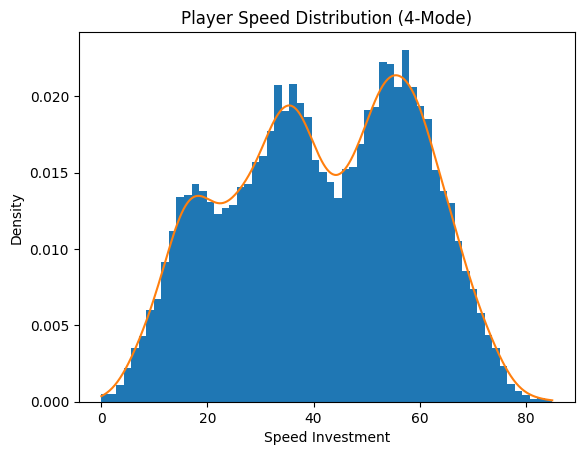

In [24]:
import matplotlib.pyplot as plt

# ----------------------------
# PARAMETERS
# ----------------------------
NUM_PLAYERS = 20000


# ----------------------------
# 4-MODE DISTRIBUTION
# ----------------------------
def generate_players(n):

    c1 = np.random.normal(17, 6, int(0.2 * n))
    c2 = np.random.normal(35, 7, int(0.35 * n))
    c3 = np.random.normal(54, 6, int(0.3 * n))
    c4 = np.random.normal(65, 6, n - len(c1) - len(c2) - len(c3))

    x = np.concatenate([c1, c2, c3, c4])
    return np.clip(x, 0, 85)


# ----------------------------
# GENERATE DATA
# ----------------------------
players = generate_players(NUM_PLAYERS)


# ----------------------------
# HISTOGRAM + DENSITY
# ----------------------------
plt.figure()

# histogram (density normalized)
counts, bins, _ = plt.hist(players, bins=60, density=True)

# smooth curve using simple KDE approximation
from scipy.stats import gaussian_kde
kde = gaussian_kde(players)

x_grid = np.linspace(0, 85, 500)
plt.plot(x_grid, kde(x_grid))

plt.title("Player Speed Distribution (4-Mode)")
plt.xlabel("Speed Investment")
plt.ylabel("Density")

plt.show()

In [9]:
# ----------------------------
# PARAMETERS
# ----------------------------
TOTAL_BUDGET = 100
step_alloc = 1  # finer grid for accuracy

sp = 80
pct = 0.997

# ----------------------------
# CORE FUNCTIONS
# ----------------------------
def research(x):
    return 200_000 * np.log(1 + x) / np.log(1 + 100)

def scale(x):
    return 7 * x / 100

def speed_multiplier(p):
    return 0.1 + 0.8 * p


# ----------------------------
# COMPUTE MULTIPLIER
# ----------------------------
mult = speed_multiplier(pct)

print(f"Speed: {sp}")
print(f"Percentile: {pct*100:.2f}%")
print(f"Multiplier: {mult:.4f}")


# ----------------------------
# OPTIMIZE R,S
# ----------------------------
best = (-1e18, 0, 0)

for r in range(0, TOTAL_BUDGET - sp + 1, step_alloc):
    s = TOTAL_BUDGET - sp - r
    if s < 0:
        continue

    val = research(r) * scale(s) * mult - (r + s + sp)

    if val > best[0]:
        best = (val, r, s)

print("\nOptimal Allocation:")
print(f"R = {best[1]}, S = {best[2]}")
print(f"PnL = {best[0]:,.2f}")

Speed: 80
Percentile: 99.70%
Multiplier: 0.8976

Optimal Allocation:
R = 6, S = 14
PnL = 74,078.60
